# Logistic Regression from Scratch

## 1. Data Preparation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:

# Define features: column 0 is Age, column 1 is Ticket Price
X = np.array([
    [10 , 3 ],
    [20 , 5 ],
    [35, 20],
    [50, 10],
])

# Define target labels: 0 (did not survive), 1 (survived)
y = np.array([0, 0, 1, 1])

## 2. The Sigmoid Function

In [3]:
def sigmoid(z):
  """
  Computes the sigmoid of z.
  Args:
      z: A scalar or numpy array of any size.
  Returns:
      s: sigmoid(z)
  """
  return 1 / (1 + np.exp(-z))

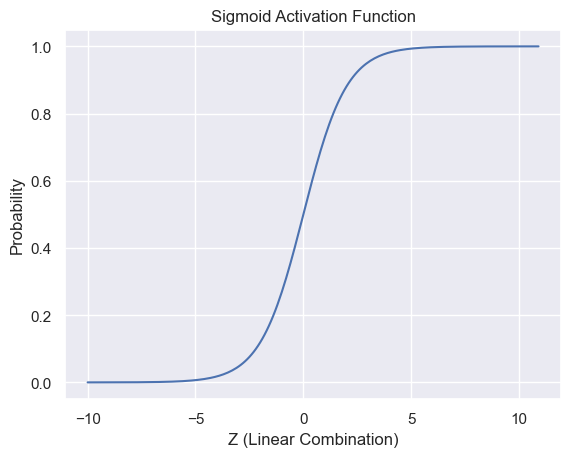

In [4]:
# Create an array of values from -10 to 10 to visualize the S-curve
z = np.arange(-10, 11, 0.1)
sigmoid_values = sigmoid(z)

# Plot the sigmoid function
plt.plot(z, sigmoid_values)
plt.title("Sigmoid Activation Function")
plt.xlabel("Z (Linear Combination)")
plt.ylabel("Probability")
plt.grid(True)

## 3. Making Predictions

In [5]:
# Initialize weights (W) and bias (b) with arbitrary small values to test the prediction logic
w_init = np.array([0.5, -2])
b_init = 0.01

In [6]:
def make_prediction(X, W, b, threshold=0.5):
  """
  Calculates the model output for each example in X.
  """
  m = X.shape[0]
  prob_list = np.zeros((m,))

  for i in range(m):
    # Calculate z = w1*x1 + w2*x2 + ... + b
    z = np.dot(W, X[i]) + b
    # Convert z into a probability
    prob_list[i] = sigmoid(z)

  # If probability > threshold, return True (1), else False (0)
  prediction = (prob_list > threshold)
  return prediction

# Test with initial weights
print("Initial Predictions:", make_prediction(X, w_init, b_init))

Initial Predictions: [False  True False  True]


## 4. Cost Function

In [7]:
def compute_cost(X, y, W, b):
  """
  Computes the Binary Cross-Entropy Cost.
  """
  m = X.shape[0]
  total_cost = 0.0

  for i in range(m):
    z = np.dot(W, X[i]) + b
    prob = sigmoid(z)
    # Log Loss formula: -[y*log(p) + (1-y)*log(1-p)]
    # We sum the inner part here and negate later
    total_cost += (y[i] * np.log(prob)) + ((1 - y[i]) * np.log(1 - prob))

  # Average the cost and negate
  return total_cost / (-m)

print(f"Initial Cost: {compute_cost(X, y, w_init, b_init):.4f}")

Initial Cost: 5.8777


## 5. Gradient Computation

In [8]:
def calculate_gradient(X, y, W, b):
  """
  Computes the partial derivatives of the cost w.r.t parameters.
  """
  m, n = X.shape
  dj_dw = np.zeros((n,))
  dj_db = 0.0

  for i in range(m):
    z = np.dot(W, X[i]) + b
    prob = sigmoid(z)
    # Difference between prediction and actual label
    error = prob - y[i]

    # Gradient for bias
    dj_db += error

    # Gradient for each weight
    for j in range(n):
      dj_dw[j] += error * X[i, j]

  # Return average gradients
  return dj_dw / m, dj_db / m